In [1]:
pip install -U mplhep

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install "numpy>=2.0,<2.3" --force-reinstall

  Using cached numpy-2.2.6-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.6-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
Note: you may need to restart the kernel to use updated packages.


In [1]:
# python
import sys
import os
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local

sidm_path = str(os.getcwd()).split("/sidm")[0]
# sidm_path = str(sys.path[0]).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, cutflow
from sidm.tools import llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
from tqdm.notebook import tqdm
import coffea.util
import numpy as np
import mplhep as hep
import yaml
from sidm.tools.utilities import plot_data_mc
from pathlib import Path

In [2]:
# Load signal sample names from YAML files
yaml_file_path = "../../configs/ntuples/signal_2mu2e_v10.yaml"
with open(yaml_file_path, "r") as file:
    data = yaml.safe_load(file)

signals_2mu2e_all = list(
    data["llpNanoAOD_v2"]["samples"].keys()
)

yaml_file_path = "../../configs/ntuples/signal_4mu_v10.yaml"
with open(yaml_file_path, "r") as file:
    data = yaml.safe_load(file)

signals_4mu_all = list(
    data["llpNanoAOD_v2"]["samples"].keys()
)


# Combine all signal samples
signals_all = signals_2mu2e_all + signals_4mu_all


# Check whether an out dictionary already exists
try:
    out
    print(
        "The out dictionary already exists; "
        "will use what is saved in memory if possible"
    )
except NameError:
    print(
        "WARNING! No processor output stored in memory. "
        "Will load one coffea file for each sample."
    )
    out = {}

input_dir = Path("1LJ_CR_cosmic_veto_v1_signal_full_merged_samples_v1")


# Load one merged coffea file for each signal point
for sample in signals_all:
    if sample in out:
        print(f"{sample} already found in memory; not loading file")
        continue

    input_file = input_dir / f"{sample}.coffea"
    print(f"Loading {input_file}")

    try:
        output = coffea.util.load(input_file)
    except FileNotFoundError:
        print(f"**** File not found: {input_file}")
        continue
    except Exception as error:
        print(f"**** Failed to load {input_file}: {error}")
        continue

    # Support the possible output structures:
    # output["out"][sample] or output[sample]
    if "out" in output and sample in output["out"]:
        out[sample] = output["out"][sample]
    elif sample in output:
        out[sample] = output[sample]
    else:
        print(
            f"**** Sample '{sample}' was not found inside "
            f"{input_file}"
        )
        print(f"Available top-level keys: {list(output.keys())}")
        continue

    print(f"Successfully loaded {sample}")

WARNING! No processor output stored in memory. Will load one coffea file for each sample.
Loading 1LJ_CR_cosmic_veto_v1_signal_full_merged_samples_v1/2Mu2E_100GeV_0p25GeV_0p02mm.coffea
Successfully loaded 2Mu2E_100GeV_0p25GeV_0p02mm
Loading 1LJ_CR_cosmic_veto_v1_signal_full_merged_samples_v1/2Mu2E_100GeV_0p25GeV_0p2mm.coffea
Successfully loaded 2Mu2E_100GeV_0p25GeV_0p2mm
Loading 1LJ_CR_cosmic_veto_v1_signal_full_merged_samples_v1/2Mu2E_100GeV_0p25GeV_2p0mm.coffea
Successfully loaded 2Mu2E_100GeV_0p25GeV_2p0mm
Loading 1LJ_CR_cosmic_veto_v1_signal_full_merged_samples_v1/2Mu2E_100GeV_0p25GeV_10p0mm.coffea
Successfully loaded 2Mu2E_100GeV_0p25GeV_10p0mm
Loading 1LJ_CR_cosmic_veto_v1_signal_full_merged_samples_v1/2Mu2E_100GeV_0p25GeV_20p0mm.coffea
Successfully loaded 2Mu2E_100GeV_0p25GeV_20p0mm
Loading 1LJ_CR_cosmic_veto_v1_signal_full_merged_samples_v1/2Mu2E_100GeV_1p2GeV_0p096mm.coffea
Successfully loaded 2Mu2E_100GeV_1p2GeV_0p096mm
Loading 1LJ_CR_cosmic_veto_v1_signal_full_merged_samples

In [3]:
samples_bkg = [
    "TTJets",
    "QCD_Pt15To20",
    "QCD_Pt20To30",
    "QCD_Pt30To50",
    "QCD_Pt50To80",
    "QCD_Pt80To120", 
    "QCD_Pt120To170",
    "QCD_Pt170To300", 
    "QCD_Pt300To470",
    "QCD_Pt470To600", 
    "QCD_Pt600To800", 
    "QCD_Pt800To1000",
    "QCD_Pt1000", 
    "DYJetsToLL_M10to50",
    "DYJetsToLL_M50", 
    "WW",
    "WZ",
    "ZZ",
]

samples_data= [ 
    "DoubleMuon_2018A_0",
    "DoubleMuon_2018A_1",
    "DoubleMuon_2018A_2",

    "DoubleMuon_2018B_0",
    "DoubleMuon_2018B_1",
    "DoubleMuon_2018B_2",
    "DoubleMuon_2018B_3",
    "DoubleMuon_2018B_4",
    "DoubleMuon_2018B_5",
    "DoubleMuon_2018B_6",
    "DoubleMuon_2018B_7",
    "DoubleMuon_2018B_8",
    "DoubleMuon_2018B_9",
    "DoubleMuon_2018B_10",
    "DoubleMuon_2018B_11",
    "DoubleMuon_2018B_12",
    "DoubleMuon_2018B_13",
    
    "DoubleMuon_2018C",

    "DoubleMuon_2018D_0",
    "DoubleMuon_2018D_1",
    "DoubleMuon_2018D_2",
    "DoubleMuon_2018D_3",
    "DoubleMuon_2018D_4",
    "DoubleMuon_2018D_5",
    "DoubleMuon_2018D_6",
    "DoubleMuon_2018D_7",
    "DoubleMuon_2018D_8",
    "DoubleMuon_2018D_9",
    "DoubleMuon_2018D_10",
    "DoubleMuon_2018D_11",
    "DoubleMuon_2018D_12",
    "DoubleMuon_2018D_13",
    "DoubleMuon_2018D_14",
    "DoubleMuon_2018D_15",
    "DoubleMuon_2018D_16",
    "DoubleMuon_2018D_17",
    "DoubleMuon_2018D_18",
    "DoubleMuon_2018D_19",
    "DoubleMuon_2018D_20",
    "DoubleMuon_2018D_21",
    "DoubleMuon_2018D_22",
    "DoubleMuon_2018D_23",
    "DoubleMuon_2018D_24",
    "DoubleMuon_2018D_25",
    "DoubleMuon_2018D_26",
    "DoubleMuon_2018D_27",
    "DoubleMuon_2018D_28",
    "DoubleMuon_2018D_29",
    "DoubleMuon_2018D_30",
    "DoubleMuon_2018D_31",
    "DoubleMuon_2018D_32",
    "DoubleMuon_2018D_33",
    "DoubleMuon_2018D_34",
    "DoubleMuon_2018D_35",
    "DoubleMuon_2018D_36",
    "DoubleMuon_2018D_37",
    "DoubleMuon_2018D_38",
    "DoubleMuon_2018D_39",
    "DoubleMuon_2018D_40",
    "DoubleMuon_2018D_41",
    "DoubleMuon_2018D_42",
    "DoubleMuon_2018D_43",
    "DoubleMuon_2018D_44",
    "DoubleMuon_2018D_45",
    "DoubleMuon_2018D_46",
    "DoubleMuon_2018D_47",
    "DoubleMuon_2018D_48",
    "DoubleMuon_2018D_49",
]

In [4]:
#First check if there is already an out dictionary
try:
    out
    print("The _out_ dictionary already exists; will use what is saved in memory if possible")
except NameError:
    print("WARNING! No processor output stored in the kernel's memory. Will try to load pickled coffea file for each sample instead")
    out = {}

#For each sample, try to use the data in memory if possible; if not try to load the file
#If those both fail, then raise an error and skip it
for sample in samples_bkg:
    if sample in out:
        print(f"{sample} already found in memory; not loading file")
    else:
        print(f"Loading file for sample {sample}")
        filename = sample + ".coffea"
        try: 
            output = coffea.util.load("1LJ_CR_cosmic_veto_v1_bkg_full_merged_samples_v1/"+filename)
            print("Successfully opened file")        
            out[sample] = output["out"][sample]
            # out[sample] = output["out"][sample.removesuffix("_part1")]
        except Exception:
            out[sample] = output[sample]
            # print("**** ERROR! File not found. Check the file name, or run the processor again and save the output to a pickle file using coffea.util.save")

The _out_ dictionary already exists; will use what is saved in memory if possible
Loading file for sample TTJets
Successfully opened file
Loading file for sample QCD_Pt15To20
Successfully opened file
Loading file for sample QCD_Pt20To30
Successfully opened file
Loading file for sample QCD_Pt30To50
Successfully opened file
Loading file for sample QCD_Pt50To80
Successfully opened file
Loading file for sample QCD_Pt80To120
Successfully opened file
Loading file for sample QCD_Pt120To170
Successfully opened file
Loading file for sample QCD_Pt170To300
Successfully opened file
Loading file for sample QCD_Pt300To470
Successfully opened file
Loading file for sample QCD_Pt470To600
Successfully opened file
Loading file for sample QCD_Pt600To800
Successfully opened file
Loading file for sample QCD_Pt800To1000
Successfully opened file
Loading file for sample QCD_Pt1000
Successfully opened file
Loading file for sample DYJetsToLL_M10to50
Successfully opened file
Loading file for sample DYJetsToLL_M50

In [5]:
#First check if there is already an out dictionary
try:
    out_data
    print("The _out_ dictionary already exists; will use what is saved in memory if possible")
except NameError:
    print("WARNING! No processor output stored in the kernel's memory. Will try to load pickled coffea file for each sample instead")
    out_data = {}

#For each sample, try to use the data in memory if possible; if not try to load the file
#If those both fail, then raise an error and skip it
for data in samples_data:
    if data in out_data:
        print(f"{data} already found in memory; not loading file")
    else:
        print(f"Loading file for data {data}")
        filename = data + ".coffea"
        try: 
            output = coffea.util.load("1LJ_CR_cosmic_veto_v1_data_full_merged_samples_v1/"+filename)
            print("Successfully opened file")        
            out_data[data] = output["out"][data]
            # out[sample] = output["out"][sample.removesuffix("_part1")]
        except Exception:
            out_data[data] = output[data]
            # print("**** ERROR! File not found. Check the file name, or run the processor again and save the output to a pickle file using coffea.util.save")

WARNING! No processor output stored in the kernel's memory. Will try to load pickled coffea file for each sample instead
Loading file for data DoubleMuon_2018A_0
Successfully opened file
Loading file for data DoubleMuon_2018A_1
Successfully opened file
Loading file for data DoubleMuon_2018A_2
Successfully opened file
Loading file for data DoubleMuon_2018B_0
Successfully opened file
Loading file for data DoubleMuon_2018B_1
Successfully opened file
Loading file for data DoubleMuon_2018B_2
Successfully opened file
Loading file for data DoubleMuon_2018B_3
Successfully opened file
Loading file for data DoubleMuon_2018B_4
Successfully opened file
Loading file for data DoubleMuon_2018B_5
Successfully opened file
Loading file for data DoubleMuon_2018B_6
Successfully opened file
Loading file for data DoubleMuon_2018B_7
Successfully opened file
Loading file for data DoubleMuon_2018B_8
Successfully opened file
Loading file for data DoubleMuon_2018B_9
Successfully opened file
Loading file for data

In [7]:
channels = [
    "data_control_region_1egmLj_spread_cosAlpha_mu_veto",
]

In [8]:
QCD = [
    "QCD_Pt15To20",
    "QCD_Pt20To30",
    "QCD_Pt30To50",
    "QCD_Pt50To80",
    "QCD_Pt80To120",
    "QCD_Pt120To170",
    "QCD_Pt170To300",
    "QCD_Pt300To470",
    "QCD_Pt470To600",
    "QCD_Pt600To800",
    "QCD_Pt800To1000",
    "QCD_Pt1000",
]

DY = [
    "DYJetsToLL_M10to50",
    "DYJetsToLL_M50",
]

TT = ["TTJets"]

Diboson = [
    "WW",
    "WZ",
    "ZZ"]

In [9]:
backgrounds = {
    "Diboson": Diboson,
    "TT": TT,
    "DY": DY,
    "QCD": QCD,
}

background_colors = {
    "Diboson": "#717581",
    "TT": "#3f90da",
    "DY": "#b9ac70",
    "QCD": "#832db6",
}

signal_maps = {
    "2Mu2E": ["2Mu2E_100GeV_5p0GeV_40p0mm", "2Mu2E_500GeV_1p2GeV_1p9mm", "2Mu2E_1000GeV_0p25GeV_0p2mm"],
    "4Mu": ["4Mu_100GeV_5p0GeV_40p0mm", "4Mu_500GeV_1p2GeV_1p9mm", "4Mu_1000GeV_0p25GeV_0p2mm"],
}

signal_colors = ["r", "orange", "gold", "lime", "cyan", "magenta"]

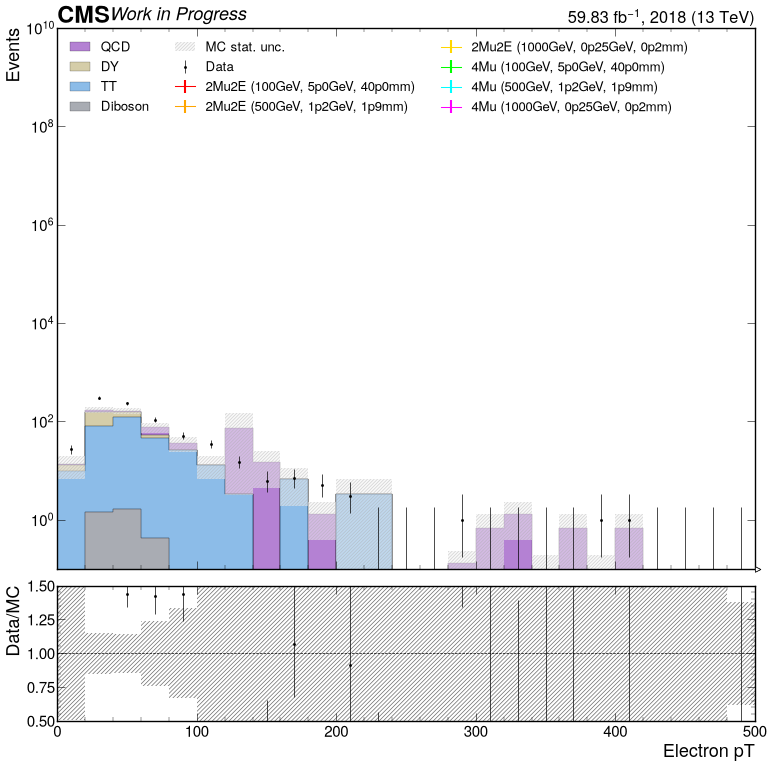

In [10]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="electron_pt",
    xlabel=r"Electron pT",
    target_bins=25,
    plot_label="Work in Progress",
)

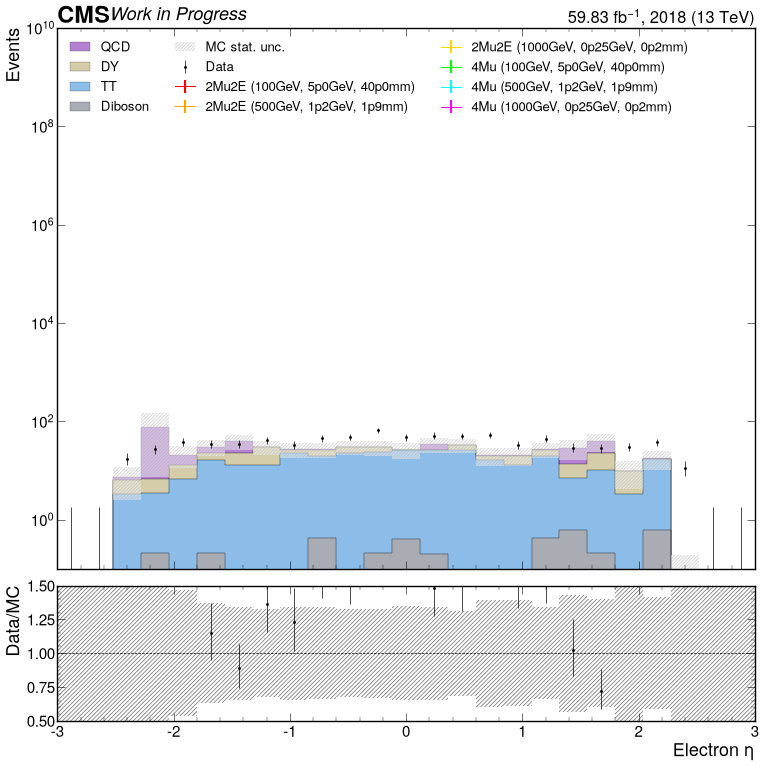

In [11]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="electron_eta",
    xlabel=r"Electron $\eta$",
    target_bins=25,
    rebin_threshold=25,
    plot_label="Work in Progress",
)

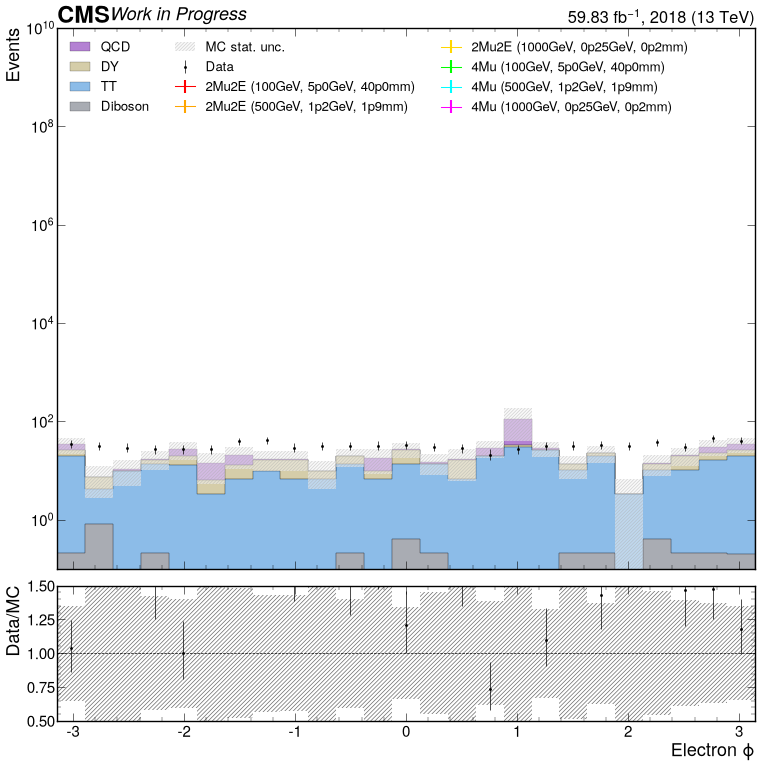

In [12]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="electron_phi",
    xlabel=r"Electron $\phi$",
    target_bins=25,
    rebin_threshold=25,
    plot_label="Work in Progress",
)

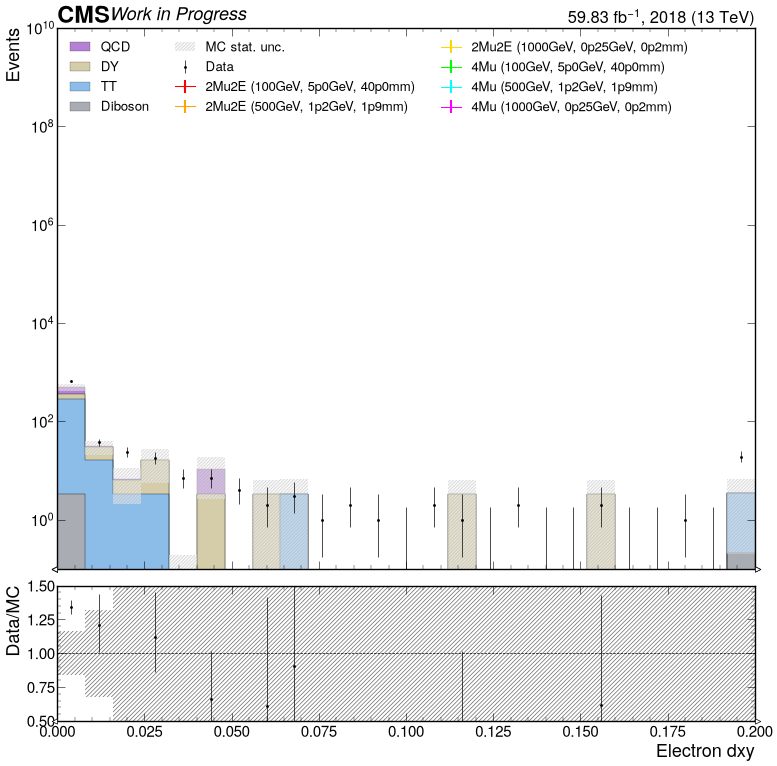

In [13]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="electron_dxy_XXLowRange",
    xlabel=r"Electron dxy",
    target_bins=25,
    plot_label="Work in Progress",
)

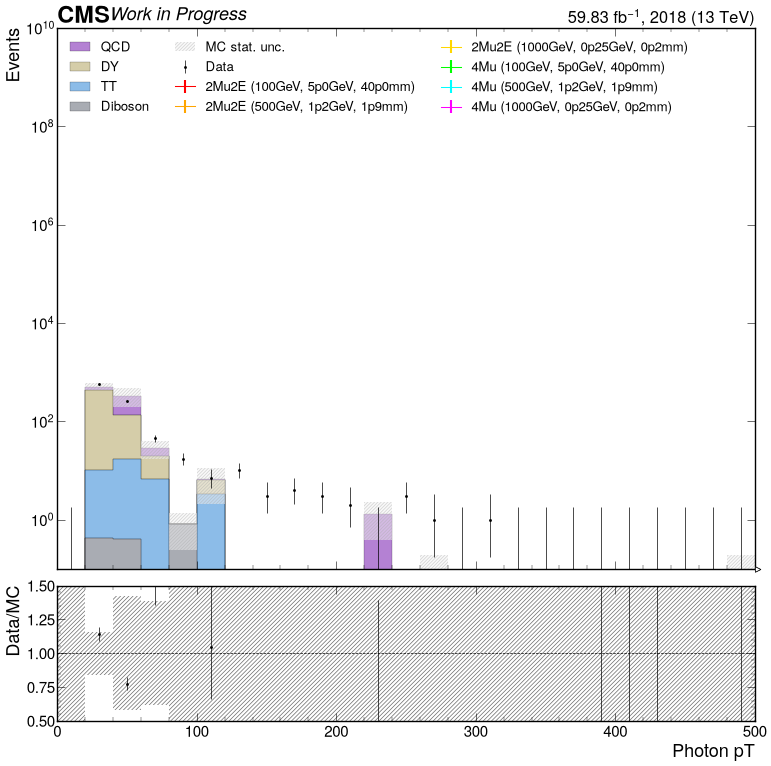

In [14]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="photon_pt",
    xlabel=r"Photon pT",
    target_bins=25,
    plot_label="Work in Progress",
)

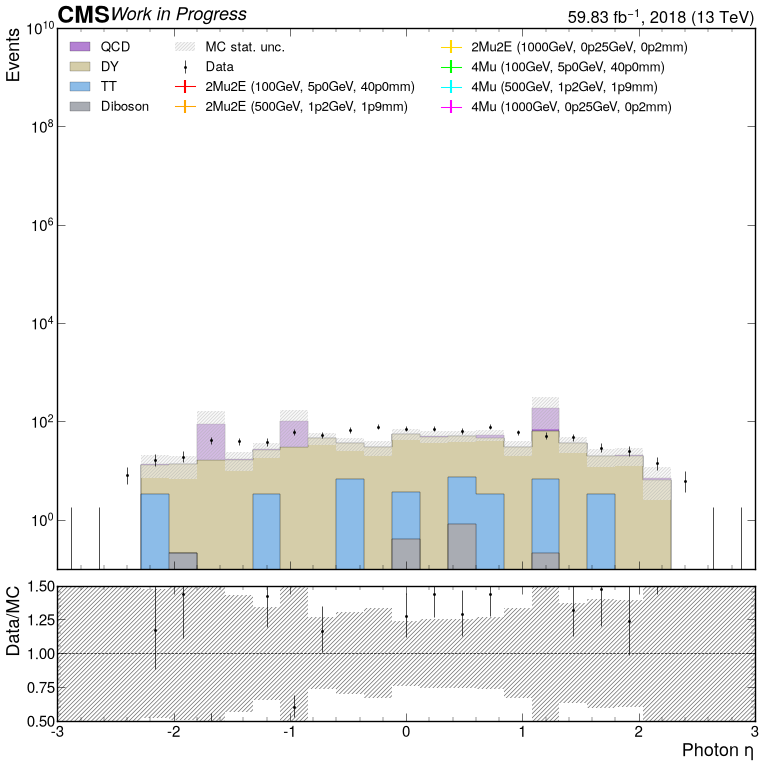

In [15]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="photon_eta",
    xlabel=r"Photon $\eta$",
    target_bins=25,
    rebin_threshold=25,
    plot_label="Work in Progress",
)

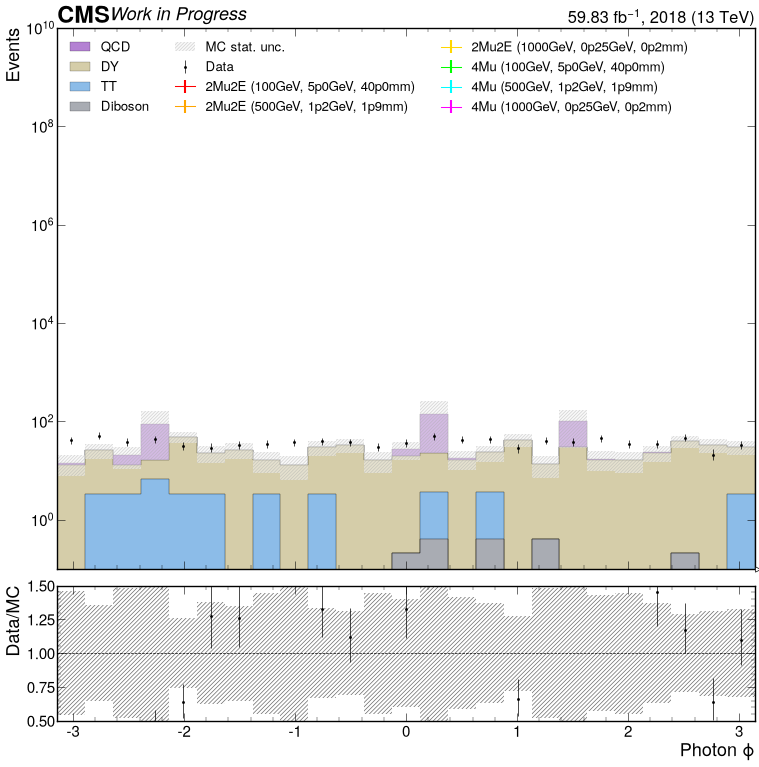

In [16]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="photon_phi",
    xlabel=r"Photon $\phi$",
    target_bins=25,
    rebin_threshold=25,
    plot_label="Work in Progress",
)

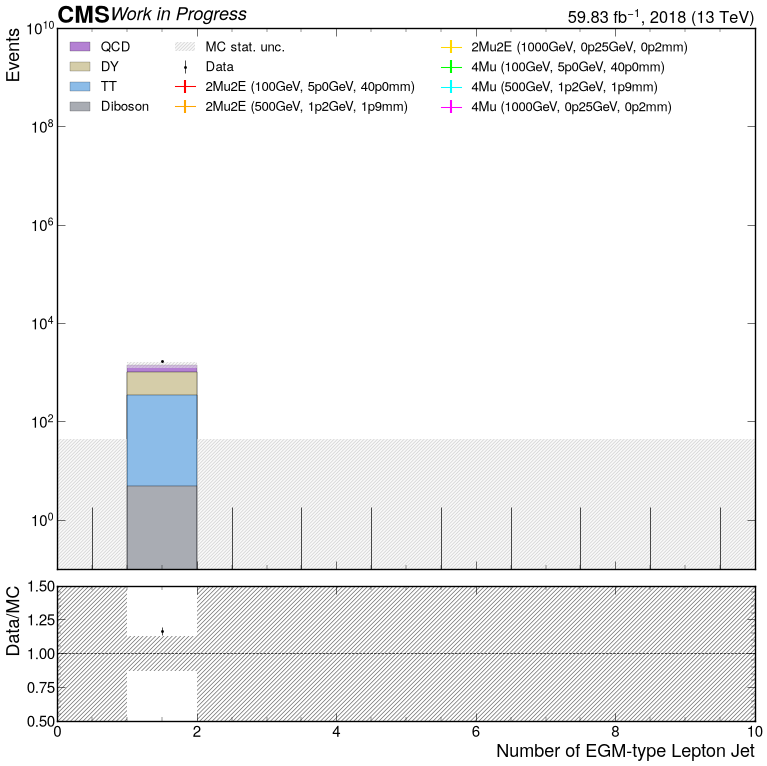

In [17]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="egm_lj_n",
    xlabel=r"Number of EGM-type Lepton Jet",
    plot_label="Work in Progress",
)

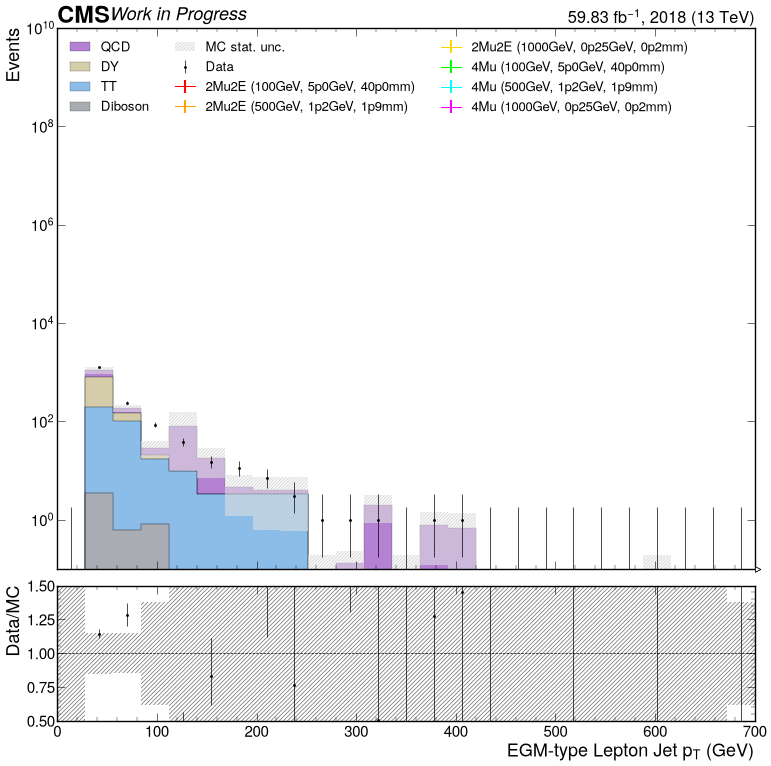

In [18]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="egm_lj_pt",
    xlabel=r"EGM-type Lepton Jet $p_T$ (GeV)",
    target_bins=25,
    plot_label="Work in Progress",
)

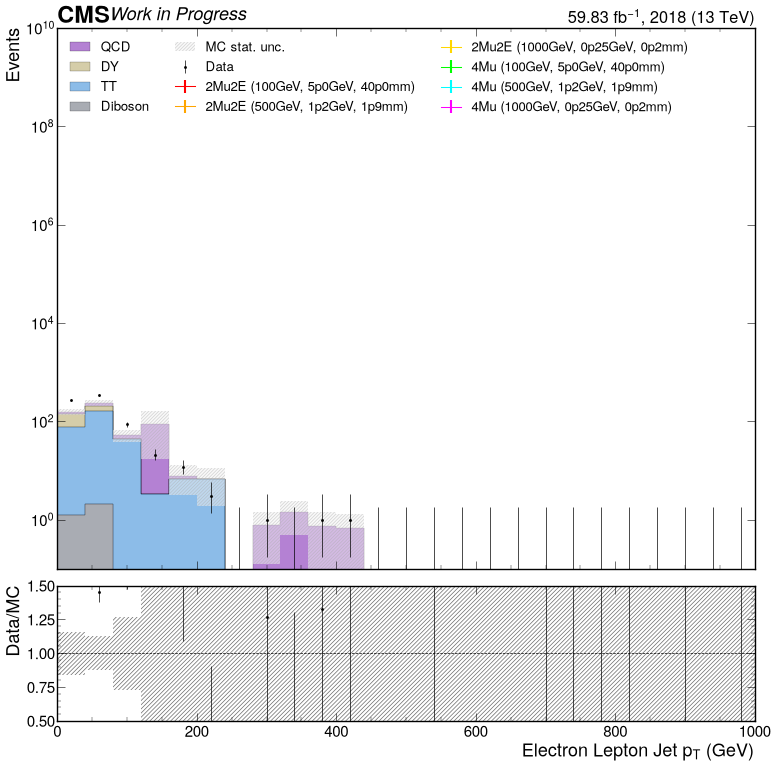

In [19]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="electron_lj_pt",
    xlabel=r"Electron Lepton Jet $p_T$ (GeV)",
    target_bins=25,
    plot_label="Work in Progress",
)

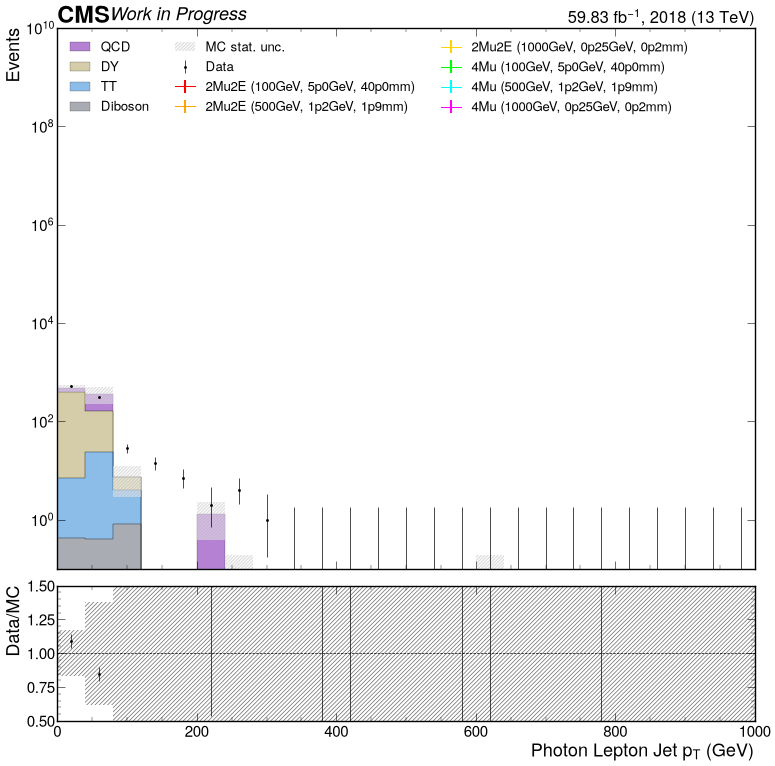

In [20]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="photon_lj_pt",
    xlabel=r"Photon Lepton Jet $p_T$ (GeV)",
    target_bins=25,
    plot_label="Work in Progress",
)

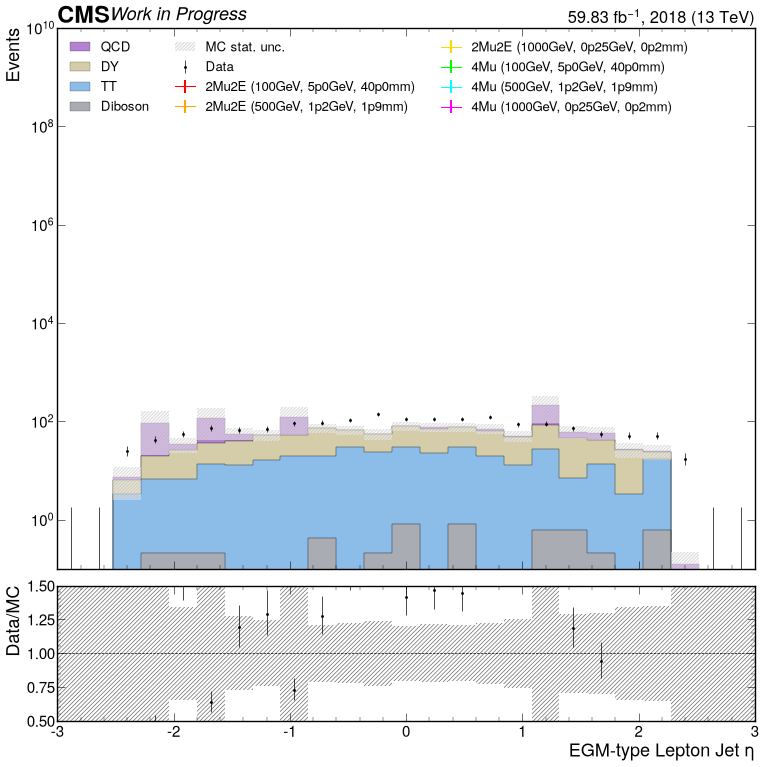

In [21]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="egm_lj_eta",
    xlabel=r"EGM-type Lepton Jet $\eta$",
    target_bins=25,
    rebin_threshold=25,
    plot_label="Work in Progress",
)

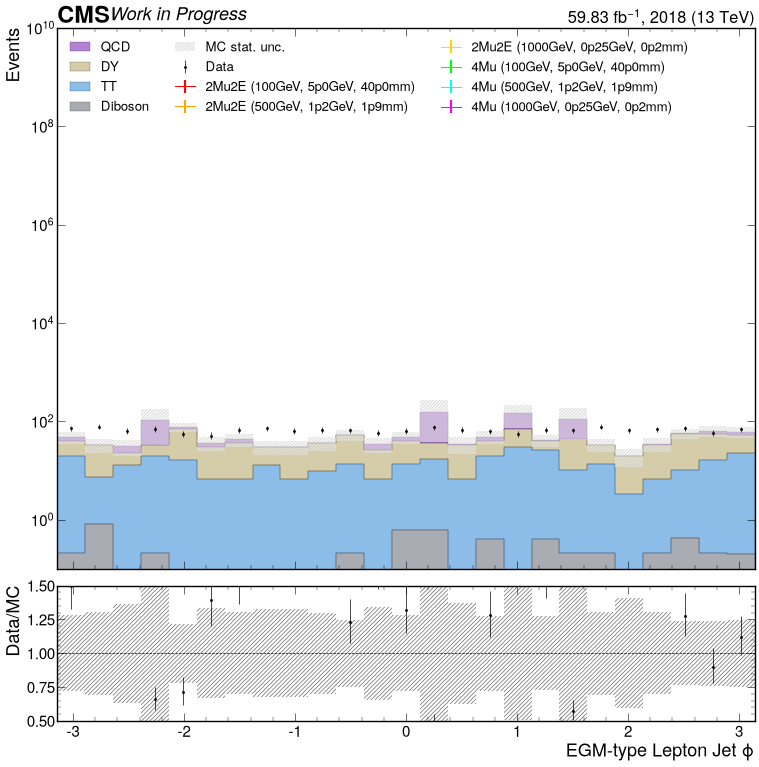

In [22]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="egm_lj_phi",
    xlabel=r"EGM-type Lepton Jet $\phi$",
    target_bins=25,
    rebin_threshold=25,
    plot_label="Work in Progress",
)

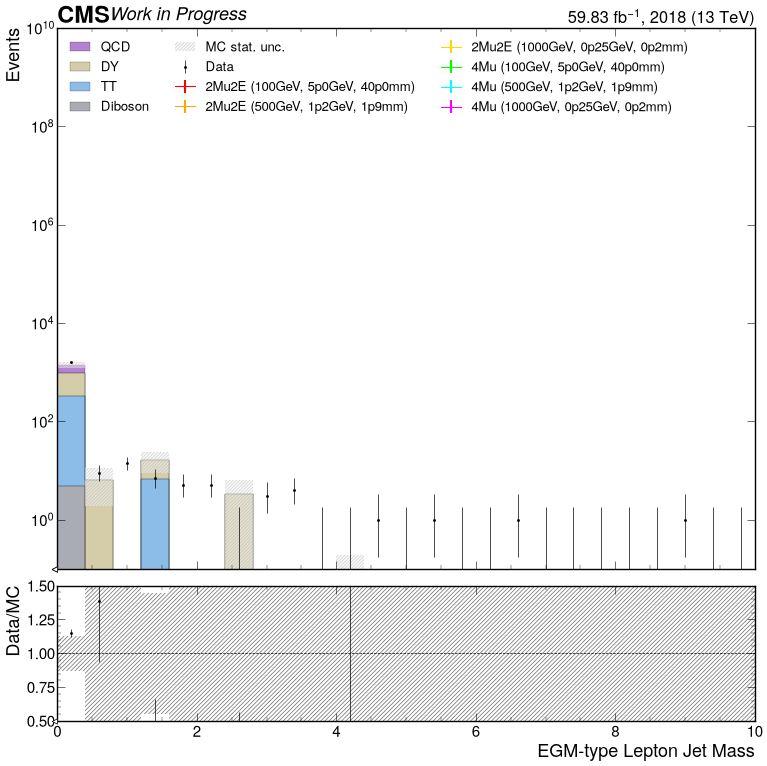

In [23]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="egm_lj_mass_small",
    xlabel=r"EGM-type Lepton Jet Mass",
    target_bins=25,
    rebin_threshold=25,
    plot_label="Work in Progress",
)

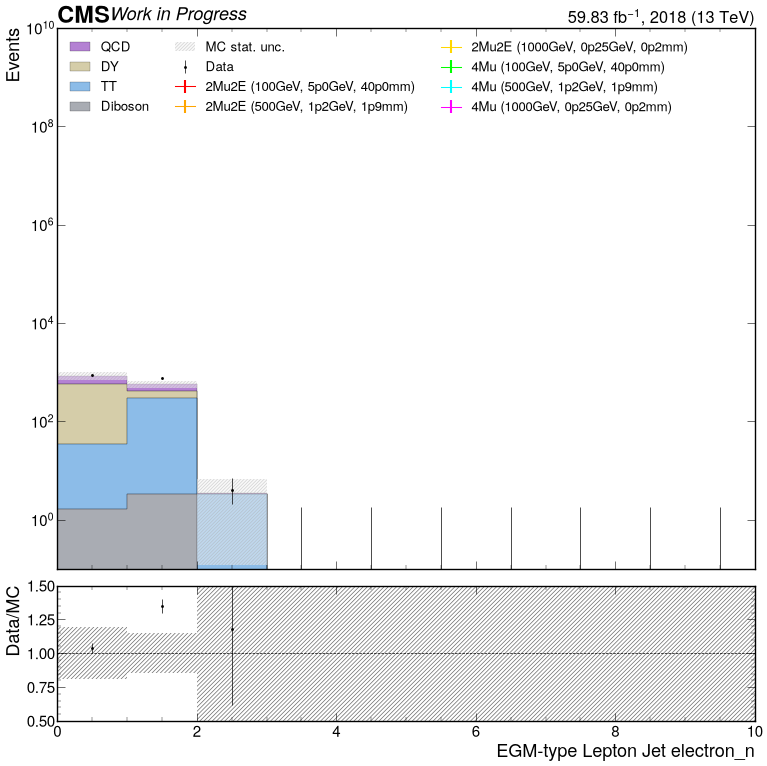

In [24]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="egm_lj_electronN",
    xlabel = r"EGM-type Lepton Jet electron_n",
    plot_label="Work in Progress",
)

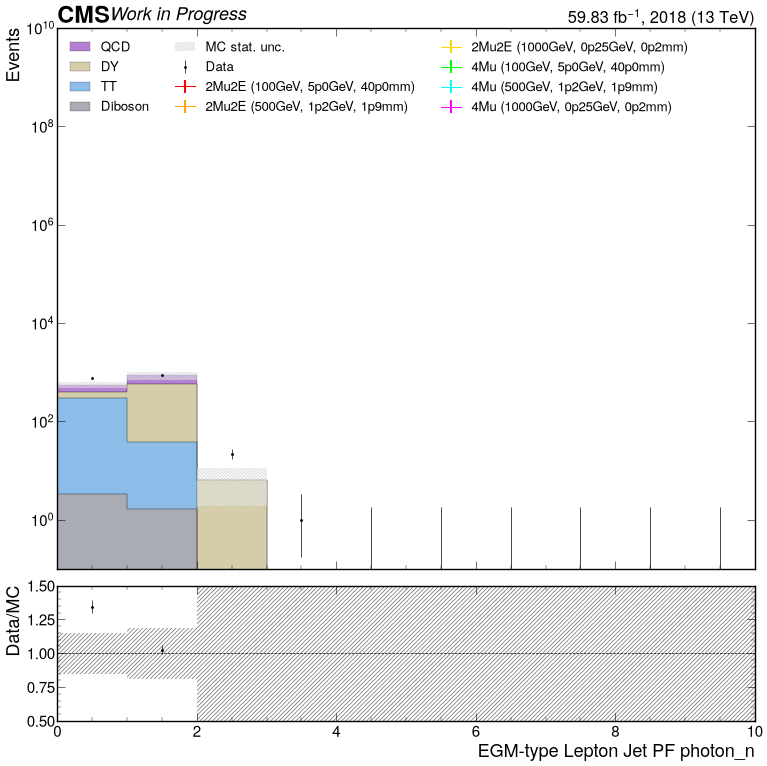

In [25]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="egm_lj_photonN",
    xlabel = r"EGM-type Lepton Jet PF photon_n",
    plot_label="Work in Progress",
)

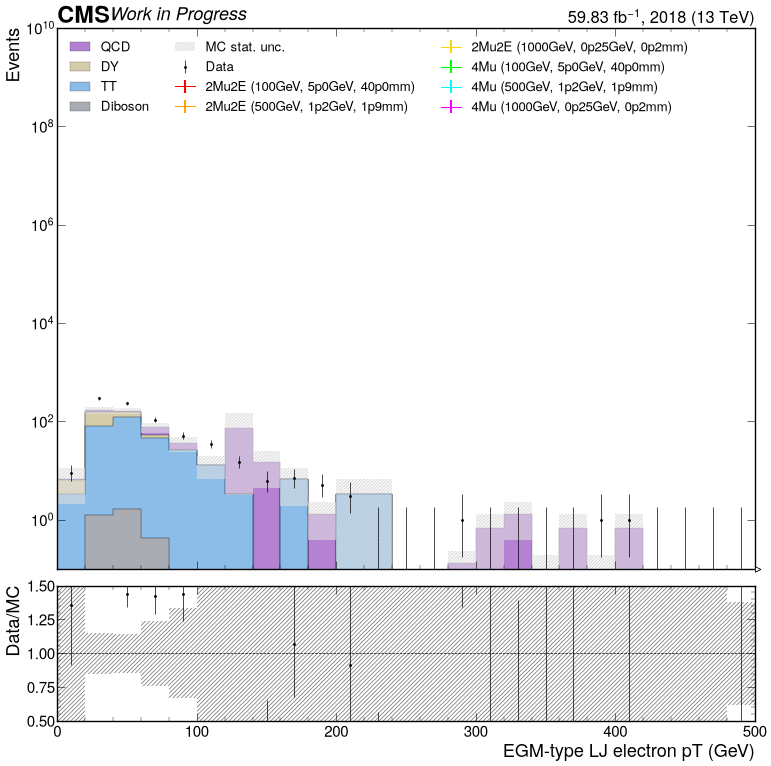

In [26]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="egm_lj_electron_pt",
    xlabel=r"EGM-type LJ electron pT (GeV)",
    target_bins=25,
    plot_label="Work in Progress",
)

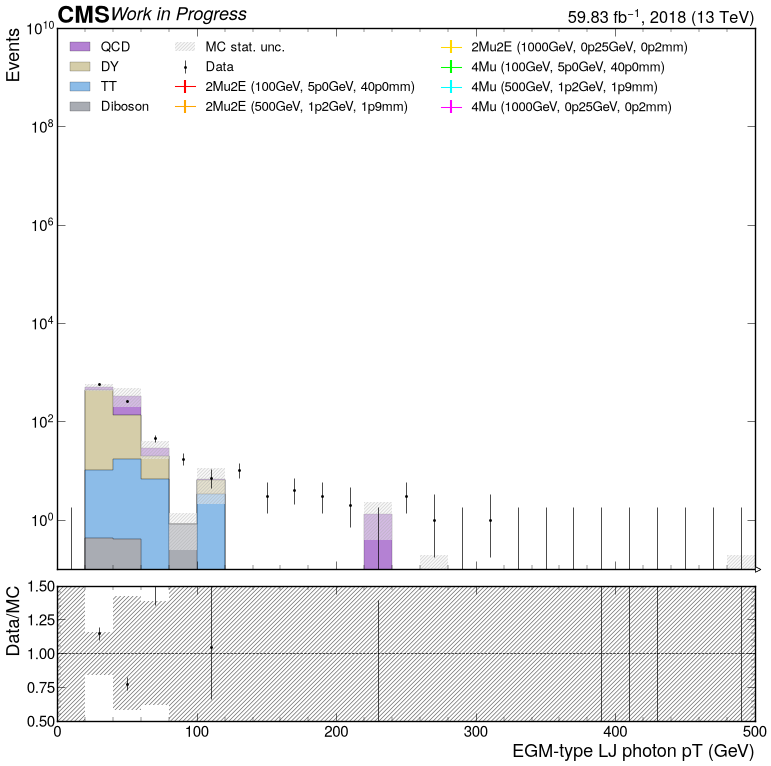

In [27]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="egm_lj_photon_pt",
    xlabel=r"EGM-type LJ photon pT (GeV)",
    target_bins=25,
    plot_label="Work in Progress",
)

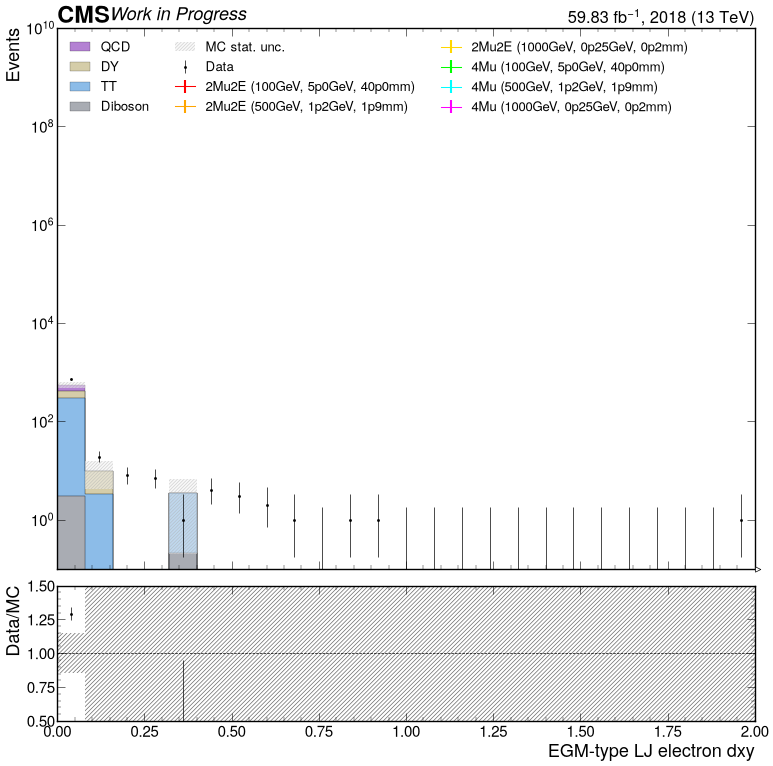

In [28]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="egm_lj_electron_dxy",
    xlabel=r"EGM-type LJ electron dxy",
    target_bins=25,
    plot_label="Work in Progress",
)

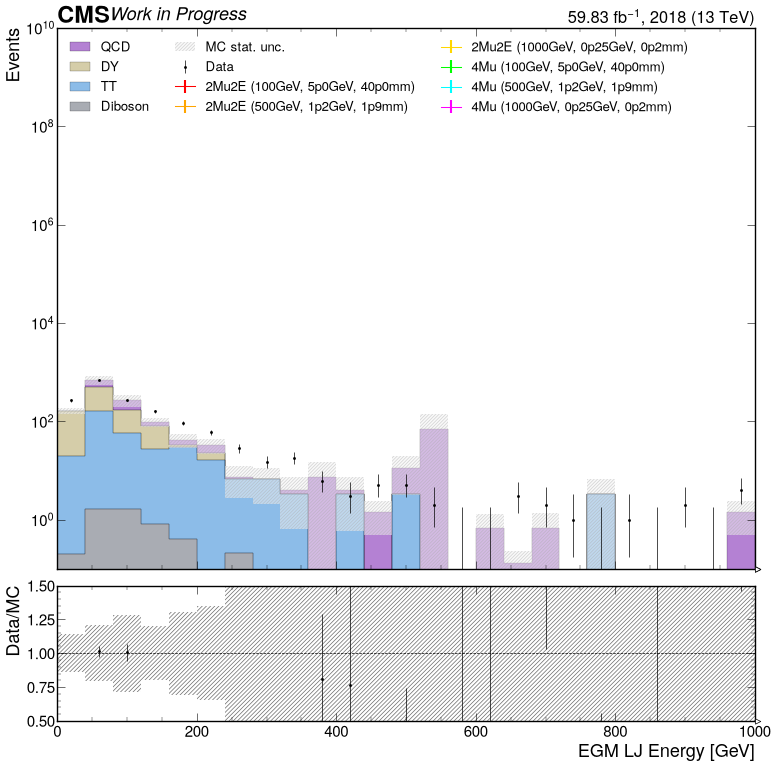

In [29]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="egm_lj_e",
    xlabel=r"EGM LJ Energy [GeV]",
    target_bins=25,
    plot_label="Work in Progress",
)

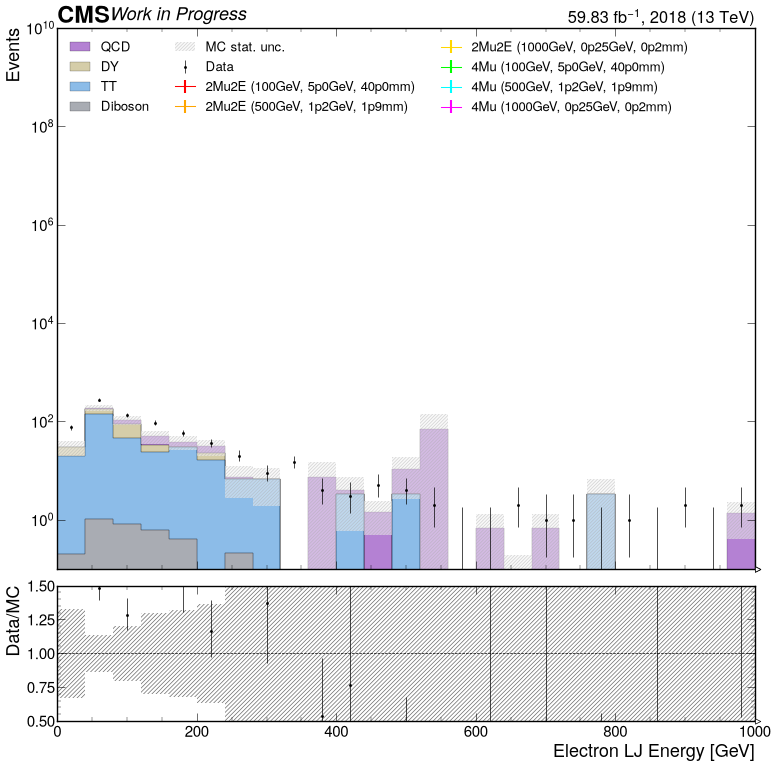

In [30]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="electron_lj_e",
    xlabel="Electron LJ Energy [GeV]",
    target_bins=25,
    plot_label="Work in Progress",
)

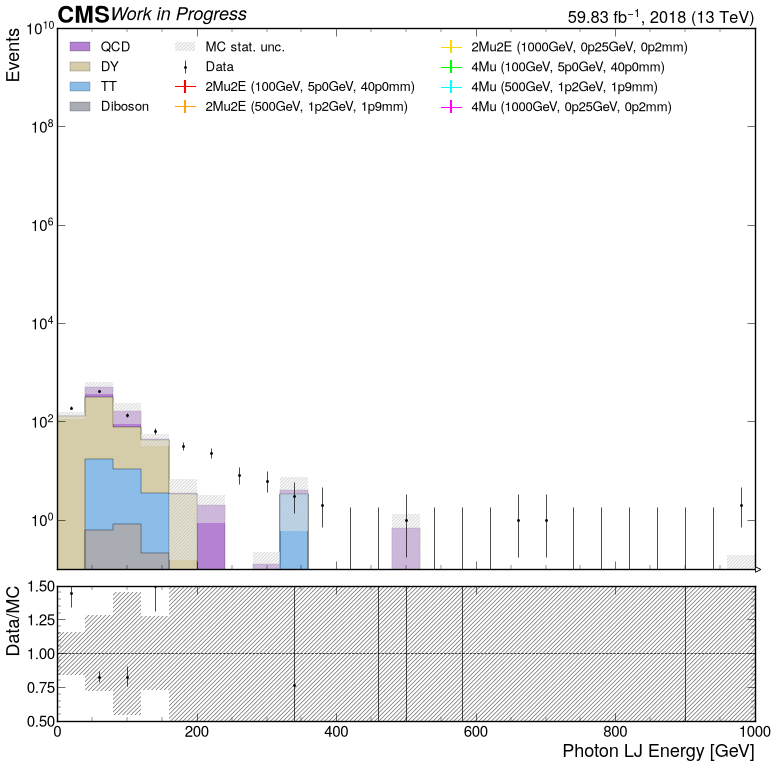

In [31]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="photon_lj_e",
    xlabel="Photon LJ Energy [GeV]",
    target_bins=25,
    plot_label="Work in Progress",
)

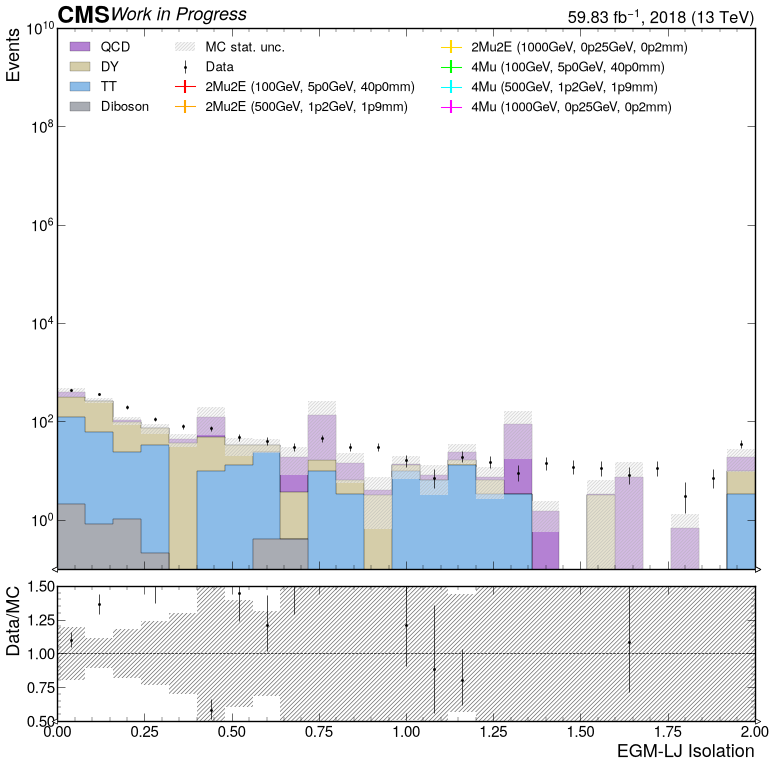

In [32]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="egm_lj_iso",
    xlabel="EGM-LJ Isolation",
    target_bins=25,
    rebin_threshold=25,
    plot_label="Work in Progress",
)

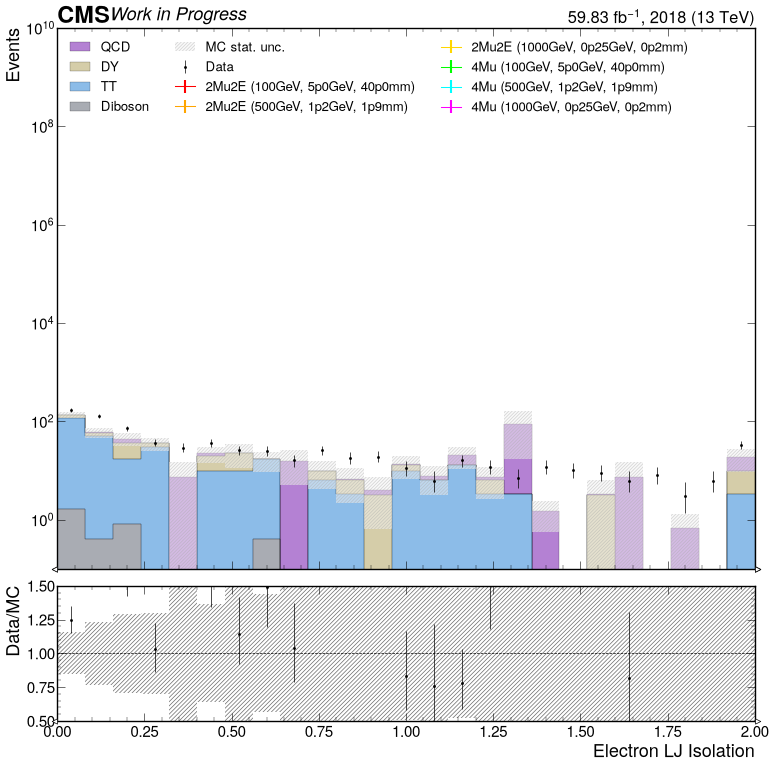

In [33]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="electron_lj_iso",
    xlabel="Electron LJ Isolation",
    target_bins=25,
    rebin_threshold=25,
    plot_label="Work in Progress",
)

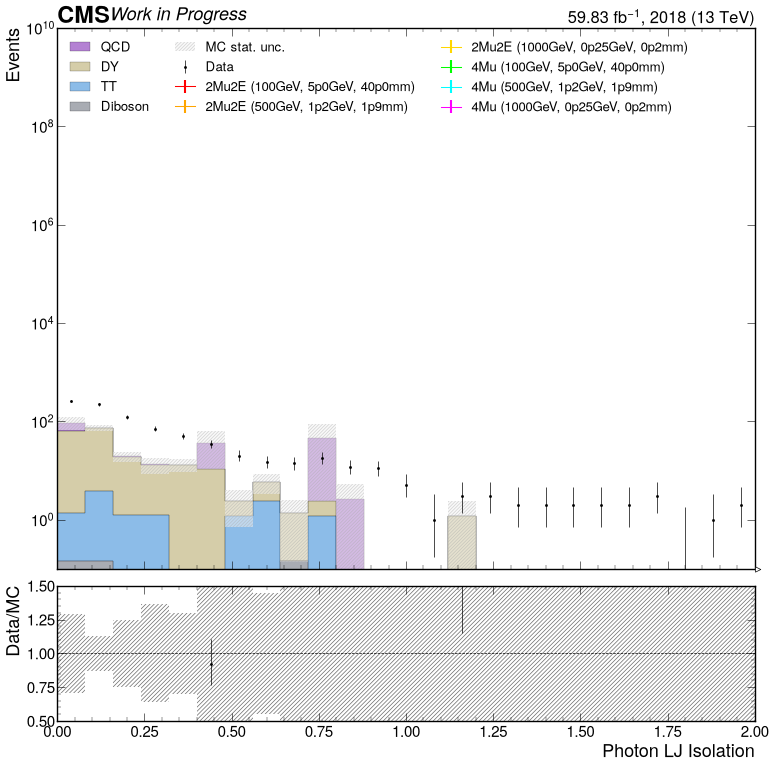

In [34]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="photon_lj_iso",
    xlabel="Photon LJ Isolation",
    target_bins=25,
    rebin_threshold=25,
    plot_label="Work in Progress",
)

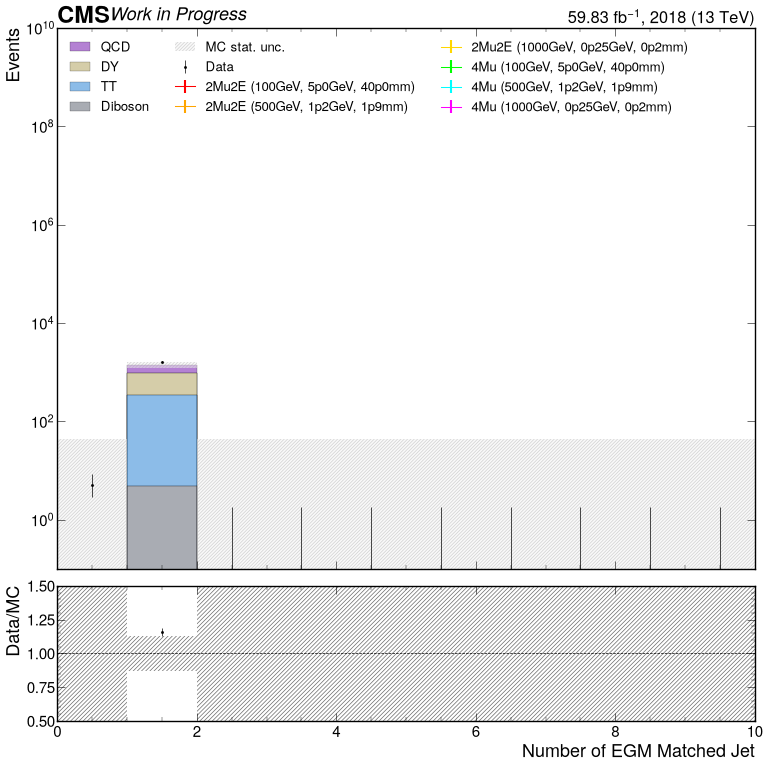

In [35]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="egm_matched_jet_n",
    xlabel="Number of EGM Matched Jet",
    plot_label="Work in Progress",
)

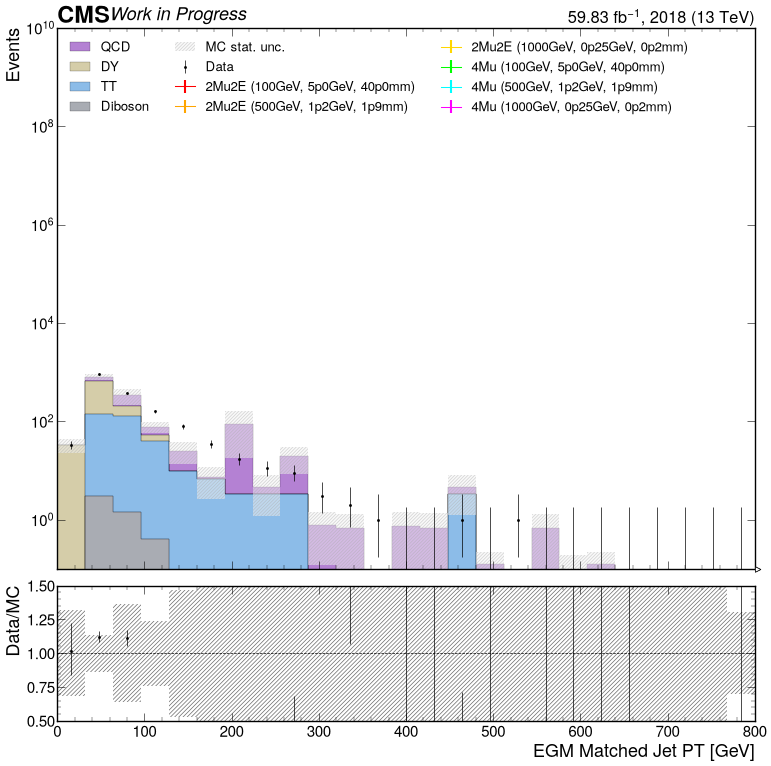

In [36]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="egm_matched_jet_pt",
    xlabel="EGM Matched Jet PT [GeV]",
    target_bins=25,
    rebin_threshold=25,
    plot_label="Work in Progress",
)

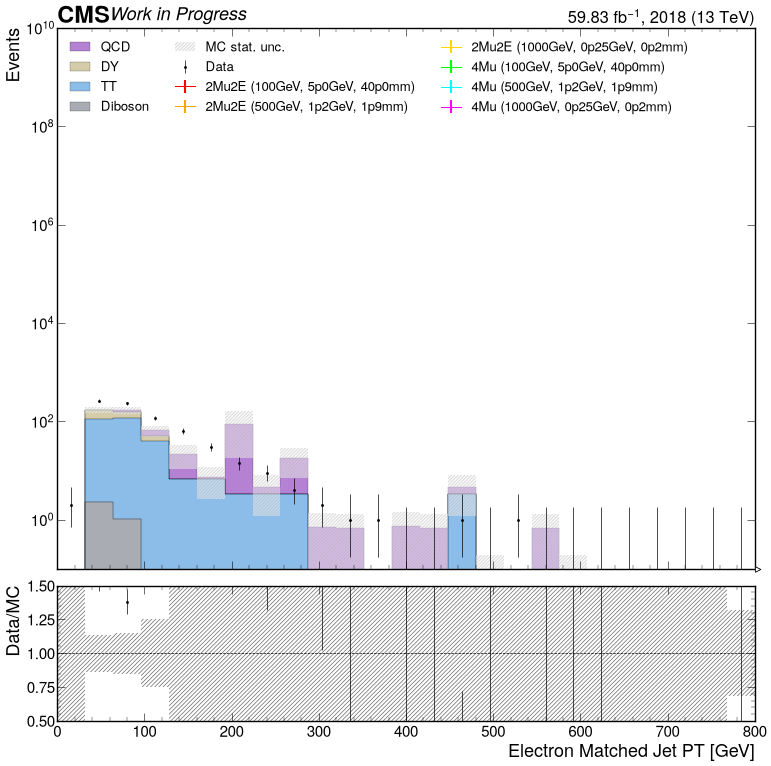

In [37]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="electron_matched_jet_pt",
    xlabel="Electron Matched Jet PT [GeV]",
    target_bins=25,
    rebin_threshold=25,
    plot_label="Work in Progress",
)

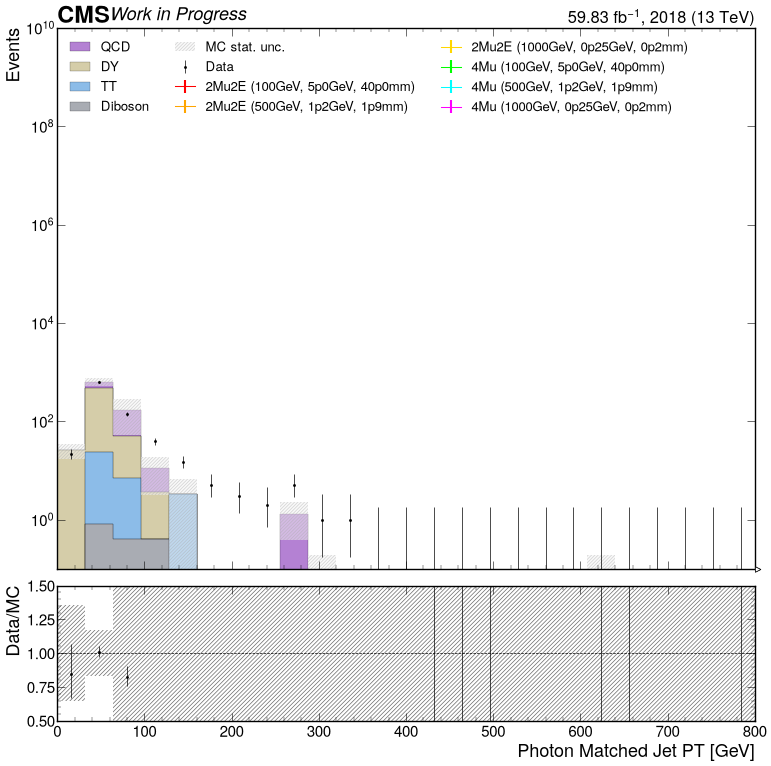

In [38]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="photon_matched_jet_pt",
    xlabel="Photon Matched Jet PT [GeV]",
    target_bins=25,
    rebin_threshold=25,
    plot_label="Work in Progress",
)

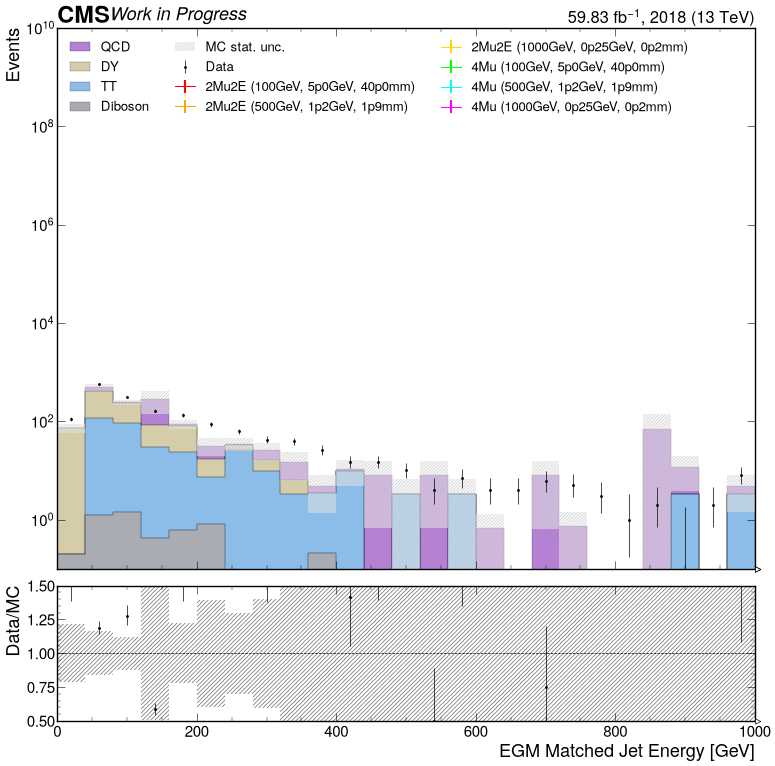

In [39]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="egm_matched_jet_e",
    xlabel="EGM Matched Jet Energy [GeV]",
    target_bins=25,
    rebin_threshold=25,
    plot_label="Work in Progress",
)

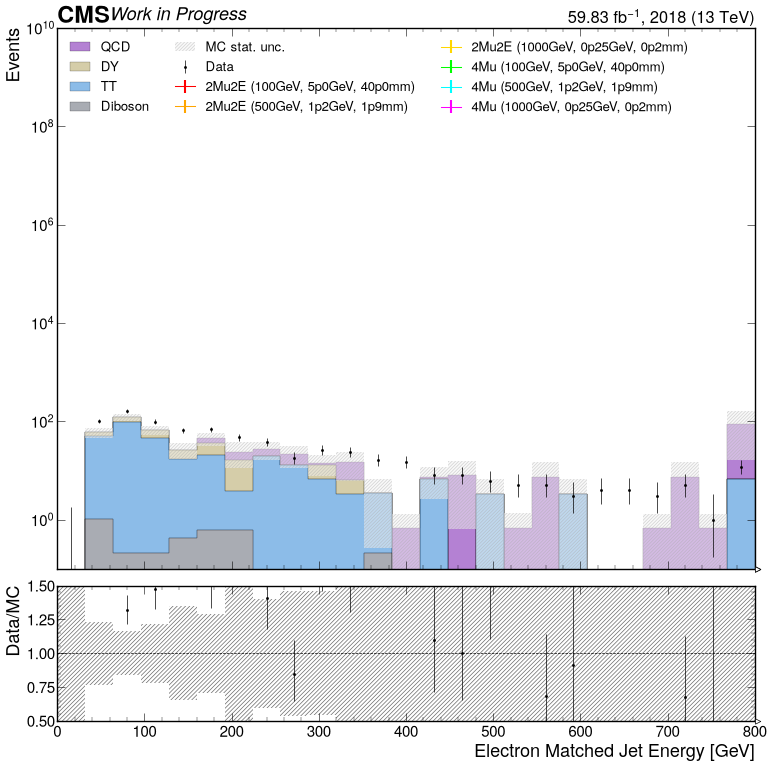

In [40]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="electron_matched_jet_e",
    xlabel="Electron Matched Jet Energy [GeV]",
    target_bins=25,
    rebin_threshold=25,
    plot_label="Work in Progress",
)

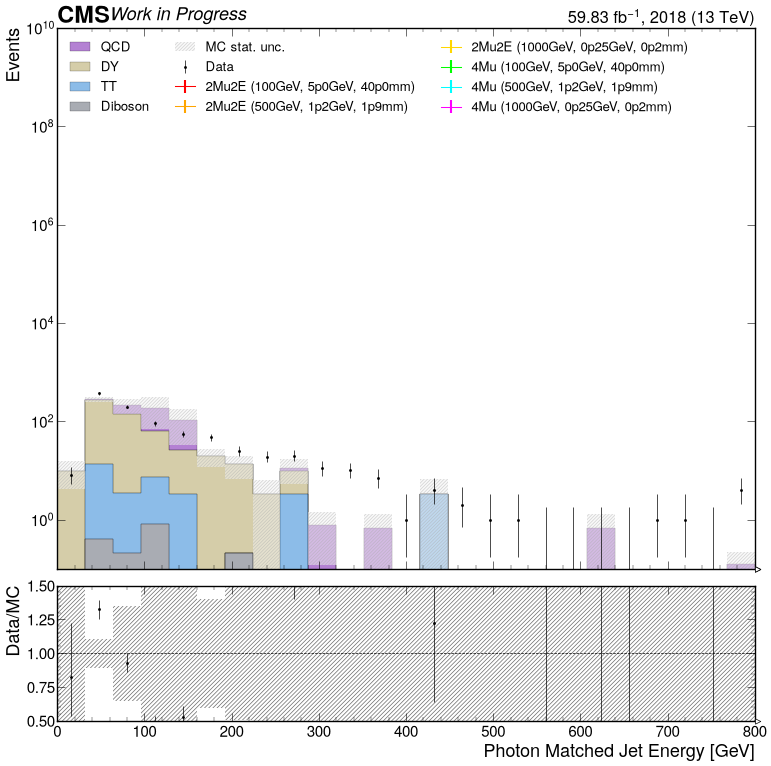

In [41]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="photon_matched_jet_e",
    xlabel="Photon Matched Jet Energy [GeV]",
    target_bins=25,
    rebin_threshold=25,
    plot_label="Work in Progress",
)

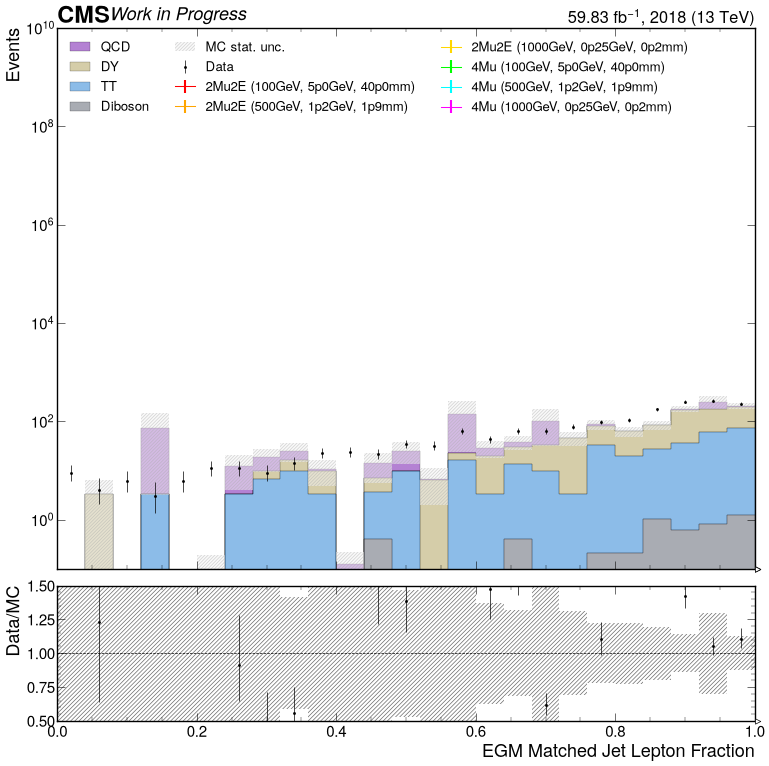

In [42]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="egm_matched_jet_lepfraction",
    xlabel="EGM Matched Jet Lepton Fraction",
    target_bins=25,
    rebin_threshold=25,
    plot_label="Work in Progress",
)

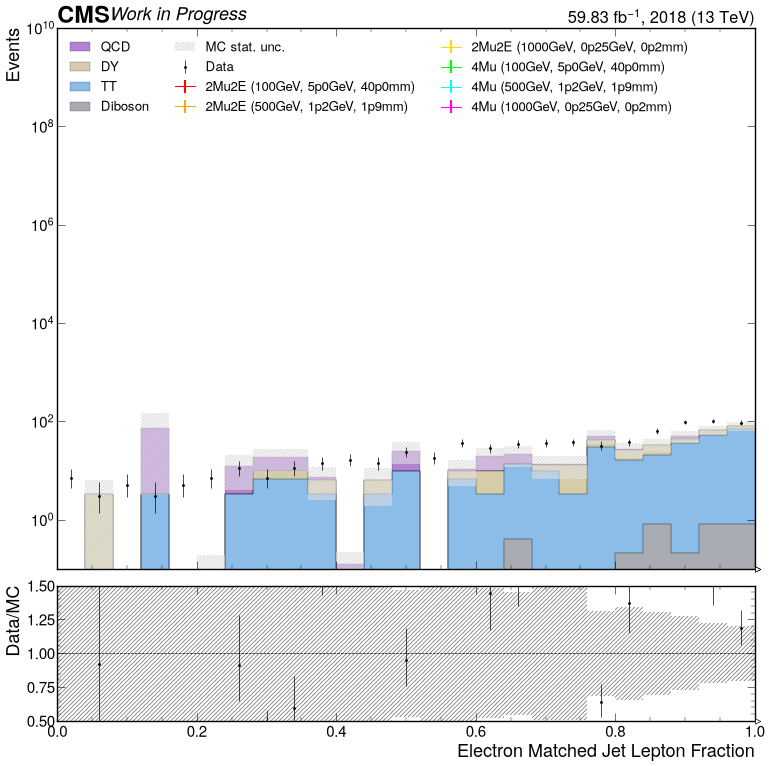

In [43]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="electron_matched_jet_lepfraction",
    xlabel="Electron Matched Jet Lepton Fraction",
    target_bins=25,
    rebin_threshold=25,
    plot_label="Work in Progress",
)

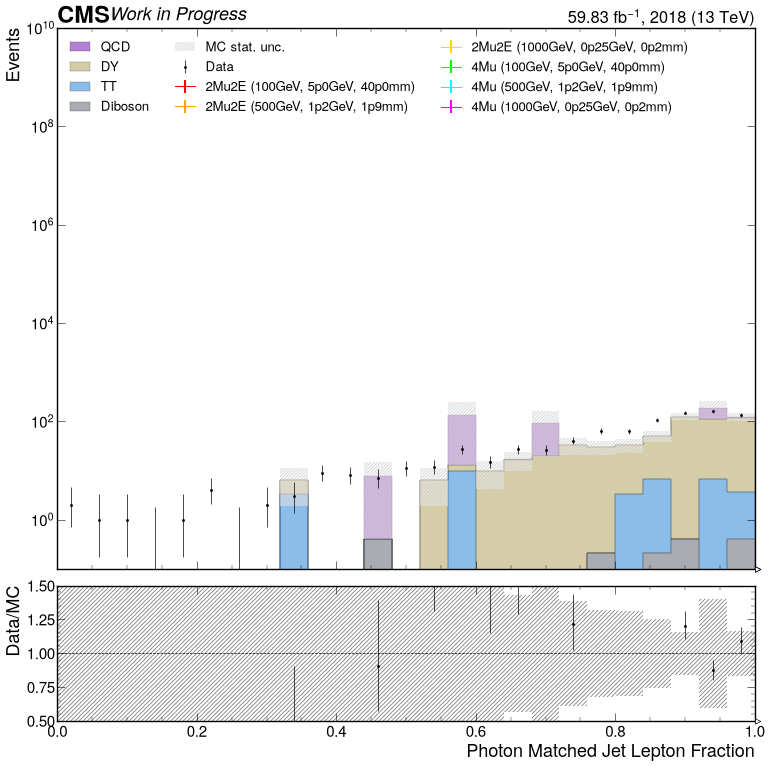

In [44]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="photon_matched_jet_lepfraction",
    xlabel="Photon Matched Jet Lepton Fraction",
    target_bins=25,
    rebin_threshold=25,
    plot_label="Work in Progress",
)

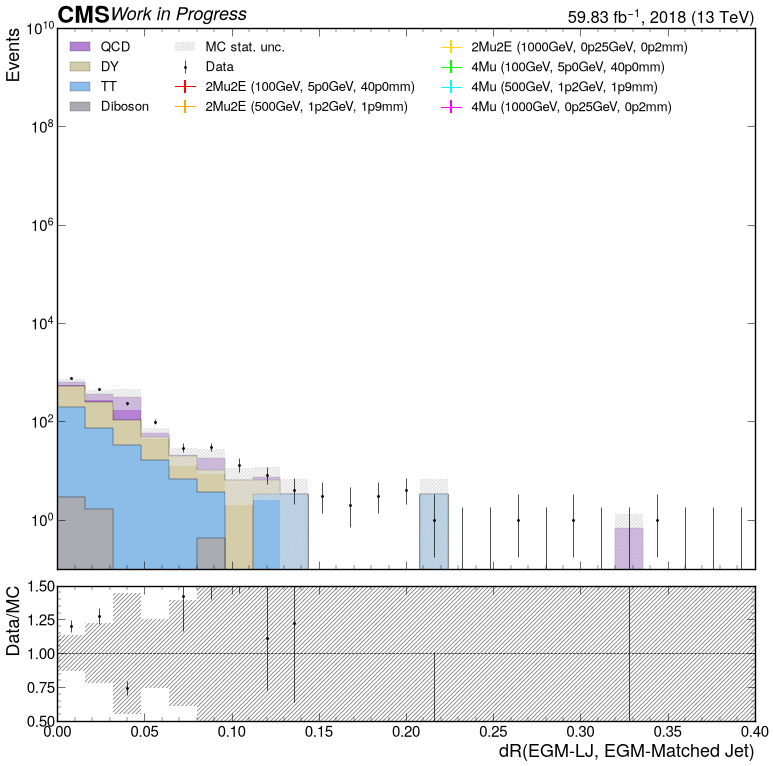

In [45]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="egm_matched_jet_lj_dR",
    xlabel="dR(EGM-LJ, EGM-Matched Jet)",
    target_bins=25,
    rebin_threshold=25,
    plot_label="Work in Progress",
)

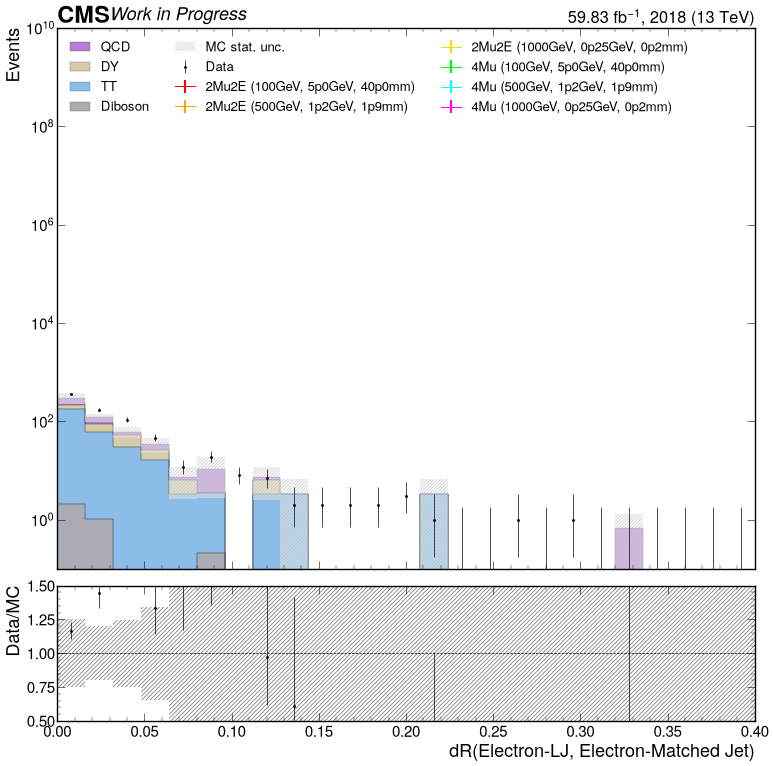

In [46]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="electron_matched_jet_lj_dR",
    xlabel="dR(Electron-LJ, Electron-Matched Jet)",
    target_bins=25,
    rebin_threshold=25,
    plot_label="Work in Progress",
)

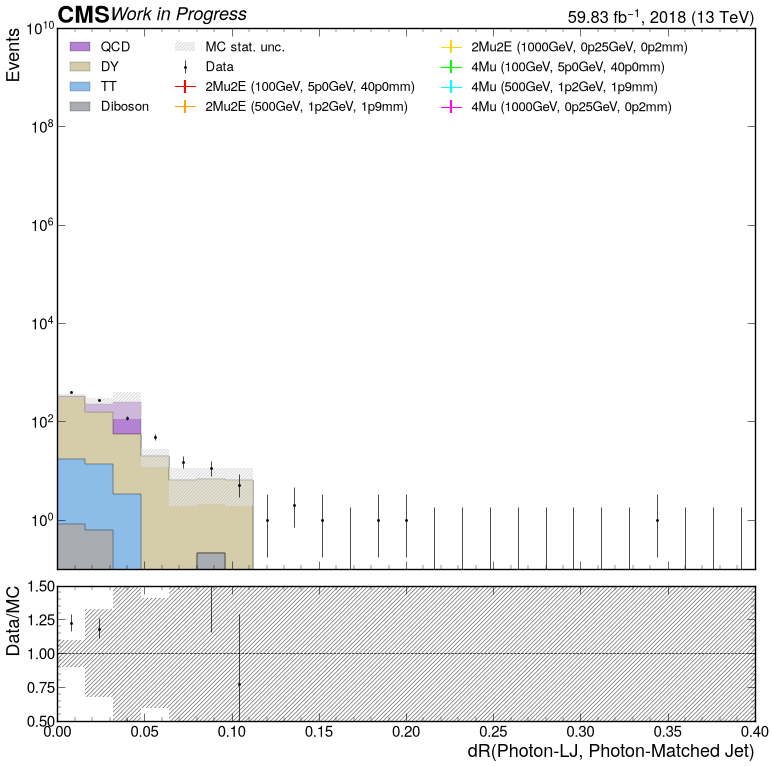

In [47]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="photon_matched_jet_lj_dR",
    xlabel="dR(Photon-LJ, Photon-Matched Jet)",
    target_bins=25,
    rebin_threshold=25,
    plot_label="Work in Progress",
)

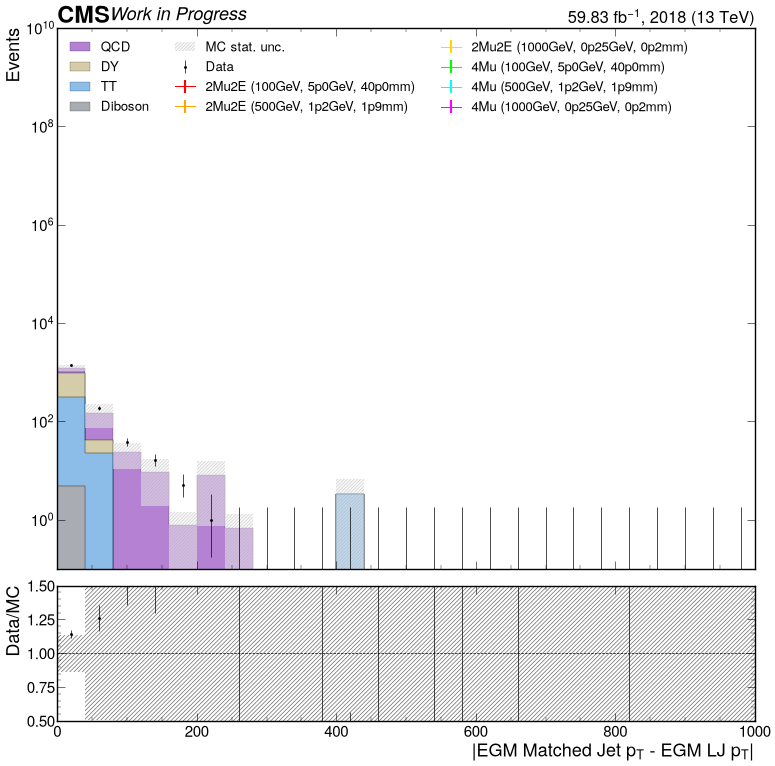

In [48]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="dpt_egm_matched_jet_lj_large",
    xlabel="|EGM Matched Jet $p_{T}$ - EGM LJ $p_{T}$|",
    target_bins=25,
    rebin_threshold=25,
    plot_label="Work in Progress",
)

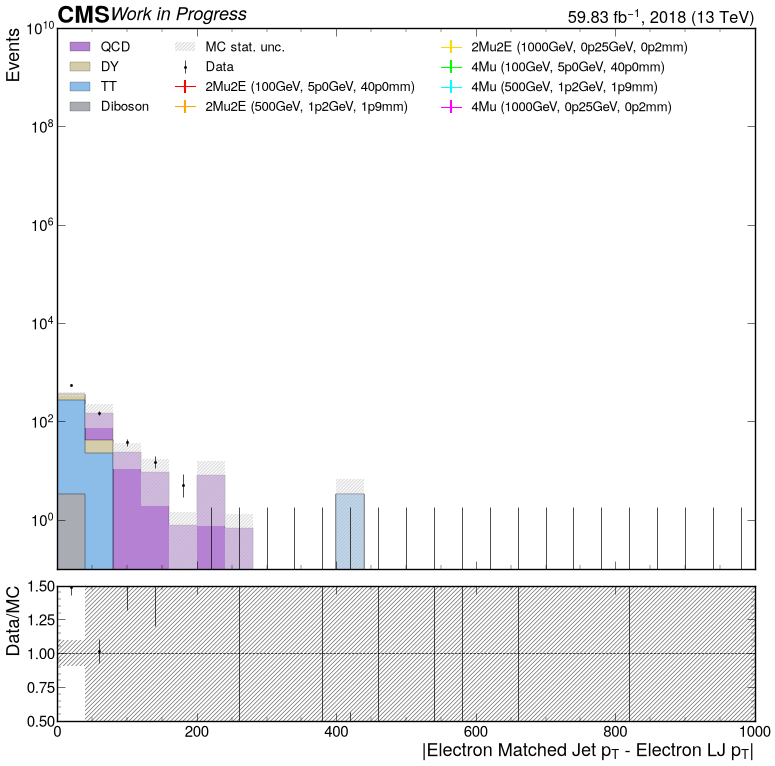

In [49]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="dpt_electron_matched_jet_lj_large",
    xlabel="|Electron Matched Jet $p_{T}$ - Electron LJ $p_{T}$|",
    target_bins=25,
    rebin_threshold=25,
    plot_label="Work in Progress",
)

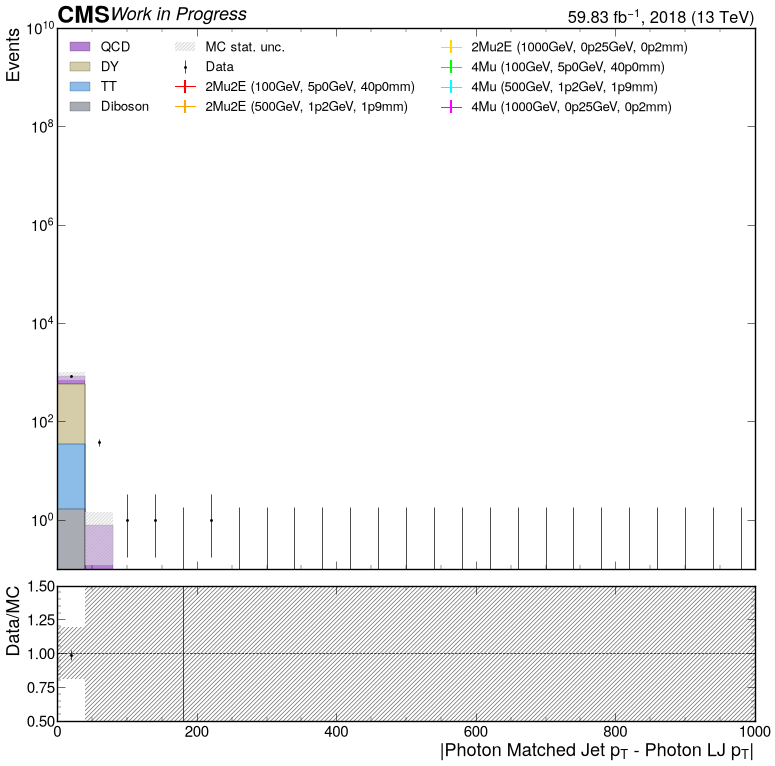

In [50]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="dpt_photon_matched_jet_lj_large",
    xlabel="|Photon Matched Jet $p_{T}$ - Photon LJ $p_{T}$|",
    target_bins=25,
    rebin_threshold=25,
    plot_label="Work in Progress",
)

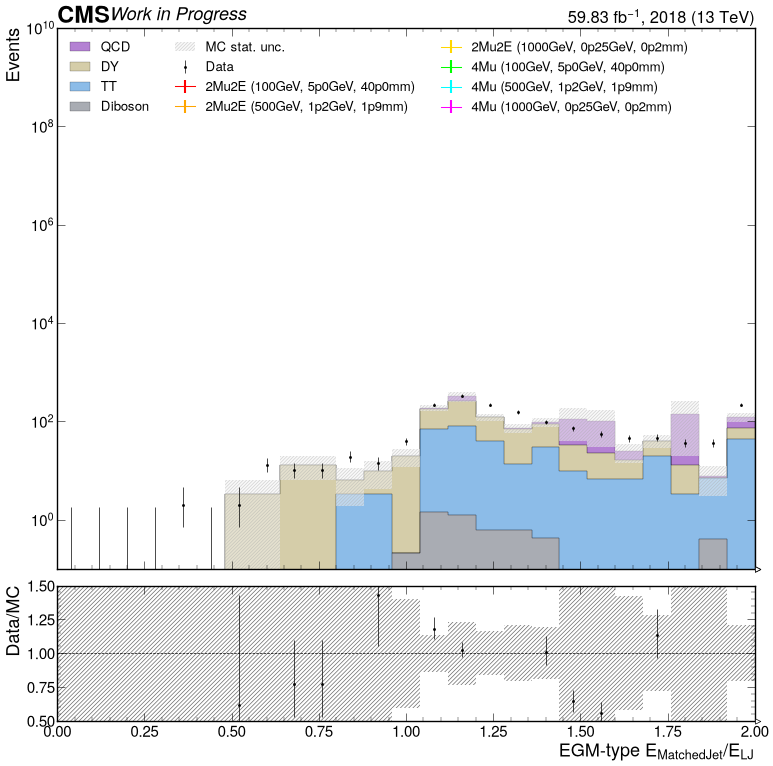

In [51]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="egm_mj_lj_Eratio",
    xlabel=r"EGM-type $E_{Matched Jet} / E_{LJ}$",
    target_bins=25,
    rebin_threshold=25,
    plot_label="Work in Progress",
)

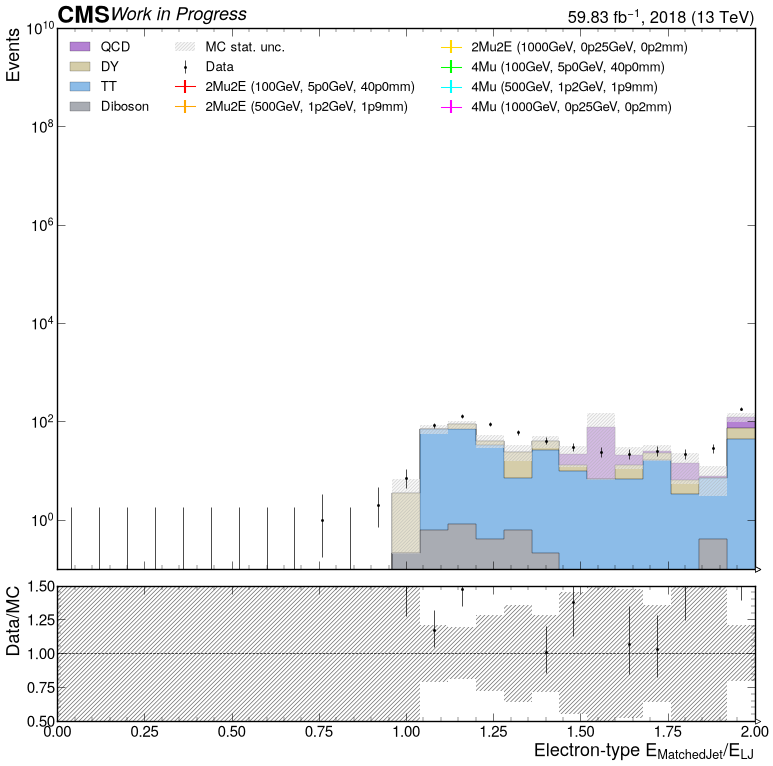

In [52]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="electron_mj_lj_Eratio",
    xlabel="Electron-type $E_{Matched Jet} / E_{LJ}$",
    target_bins=25,
    rebin_threshold=25,
    plot_label="Work in Progress",
)

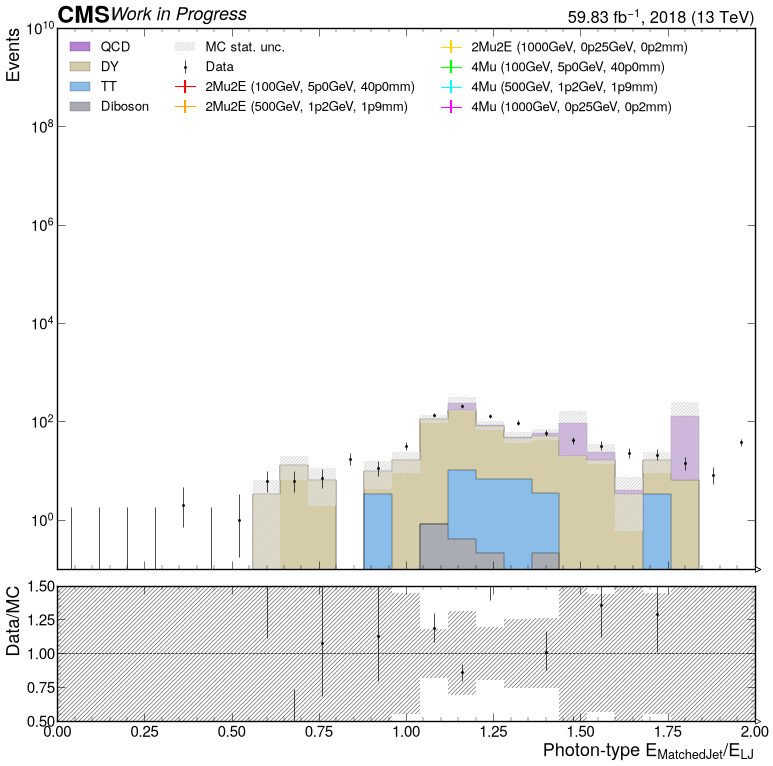

In [53]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=59.83,
    logy=True,
    variable="photon_mj_lj_Eratio",
    xlabel=r"Photon-type $E_{Matched Jet} / E_{LJ}$",
    target_bins=25,
    rebin_threshold=25,
    plot_label="Work in Progress",
)